In [5]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




In [2]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

bq_auth()

project_id = "yhcr-prd-bradfor-bia-core"

# create connection to database
con <- DBI::dbConnect(bigrquery::bigquery(), 
                      project = project_id)

print(paste0("Connected to : ", project_id))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




[1] "Connected to : yhcr-prd-bradfor-bia-core"


# Absence

In [3]:
person_ids <- read.csv('data/additional_person_ids.csv', header = TRUE)

In [4]:
absence_data = "CB_2489.cb_Absence"

absence_table <- tbl(con, absence_data) |>
    select(person_id, AcademicYear, Term, SessionsPossible, AuthorisedAbsence, UnauthorisedAbsence, OverallAbsence) 
    # convert to df
    #collect()


In [5]:
head(absence_table)

# Source:   SQL [6 x 7]
# Database: BigQueryConnection
  person_id                AcademicYear Term  SessionsPossible AuthorisedAbsence
  <chr>                    <chr>        <chr>            <dbl>             <dbl>
1 52F91FA12EF90BDACB3E5A8… 2005/2006    3Term              310                 0
2 B95634797D42DD193682749… 2005/2006    3Term              306                 2
3 478E8E6D679E0FD11259219… 2005/2006    3Term              307                31
4 A71419D65AF16313C3CAB3A… 2005/2006    3Term              308                13
5 A88EEE1F2778D4D914649C5… 2005/2006    3Term              242                45
6 432D3F547DB230459DD72FE… 2005/2006    3Term              300                28
# ℹ 2 more variables: UnauthorisedAbsence <dbl>, OverallAbsence <dbl>

In [6]:
absence_df <- collect(absence_table)

In [10]:
unique(absence_df$AcademicYear)

[1] "2005/2006" "2006/2007" "2007/2008" "2008/2009" "2009/2010" "2010/2011"
 [7] "2012/2013" "2013/2014" "2015/2016" "2016/2017" "2017/2018" "2018/2019"
[13] "2020/2021" "2011/2012" "2014/2015" "2019/2020"

In [7]:
absence_years <- absence_df |>
    filter(AcademicYear %in% c('2010/2011','2011/2012','2012/2013','2013/2014','2014/2015','2015/2016')) 
    #filter(Term %in% c('6HalfTerm', '6HalfTerms', 'Annual'))

In [14]:
unique(absence_years$Term)

[1] "3Term"      "Spring"     "5HalfTerms" "Autumn"     "6HalfTerms"
[6] "Summer"     "Annual"     "Summer6th"

In [8]:
absence_years <- absence_years |>
    mutate(Term = case_when(
            Term == '6HalfTerm' ~ '6HalfTerms',
            TRUE ~ Term)
           )

## filter by person id per cohort to get correct years

In [19]:
head(person_ids)

,person_id,NCCIS_ACADYR
,<chr>,<chr>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018


In [9]:
ids_cohort1 <- person_ids |>
    filter(NCCIS_ACADYR == '2015/2016')

In [10]:
ids_cohort2 <- person_ids |>
    filter(NCCIS_ACADYR == '2016/2017')

Check for matching IDs across 2 cohorts (as end up with duplicates for some rows later)

In [11]:
any(ids_cohort1$person_id %in% ids_cohort2$person_id)

[1] FALSE

In [12]:
any(ids_cohort2$person_id %in% ids_cohort1$person_id)

[1] FALSE

In [13]:
absence_cohort1 <- absence_years |>
    filter(person_id %in% ids_cohort1$person_id)

In [20]:
head(absence_cohort1)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
93803C8542B8D32DF040667A46E5A527B9B4097FE34AF80AC8511BA33CDBA562,2012/2013,Spring,100,0,46,46
11A6B7D401EDF61CE7539EF327B456F8E1E63696B3CFBE4D238B6657706631FF,2012/2013,5HalfTerms,306,26,32,58
8C4B58BB1E7E6D0A6CD0B9252A3D3EF1E46E13817BABF42ED3121712CA433C26,2013/2014,Autumn,138,26,1,27
104C68F94790657F0BE856CE29F63D54FB90187C2D2481457B9DCCEEE2B8755D,2011/2012,3Term,316,27,0,27
A5CAA8DEB078820DA9576EF014CE0D8E0E398885C638976EFFA14D2A0C5E500C,2011/2012,Spring,116,16,18,34
35365078CAF741CA47FFE0E4912EBC795D876E2BE13BB2C88B94730ED7989E9E,2010/2011,3Term,292,60,38,98


In [14]:
absence_cohort2 <- absence_years |>
    filter(person_id %in% ids_cohort2$person_id)

In [22]:
ids_cohort1 |> nrow()

[1] 9499

In [23]:
absence_cohort1 |> nrow()

[1] 199722

In [24]:
absence_cohort1 |> summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
8601


In [25]:
ids_cohort2 |> nrow()

[1] 9500

In [26]:
absence_cohort2 |> nrow()

[1] 240435

In [27]:
absence_cohort2 |> summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
8640


In [28]:
head(absence_cohort2)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
7F229351D45EEC7F8ECA9A59F2A9F18B551299633F5B2DE02EF05A1DF7E6FAB2,2014/2015,5HalfTerms,305,24,64,88
E756AB117DBC0B543DB47E53275F0CA95E6E604651BF944618E324526A32E8CB,2013/2014,6HalfTerms,368,36,0,36
13EF7665B8E3C0EA109952F4D6B45545718D26F5917DCEF3009028B1949D9DA7,2010/2011,3Term,298,27,0,27
E5778330D67C7A655888410094E256E02390CF17867DF7AF5C989D8AB94C118F,2013/2014,Autumn,136,10,21,31
F102A3E0E885F3E6DF01DEBA1788B6E61BFD4799CF66F488F800759DA65A5190,2015/2016,5HalfTerms,136,3,103,106
1E069287C2E2B3AD499DA76118F093F6350274C89603BBE0D25C60D43F6F9FC9,2010/2011,3Term,241,29,35,64


In [15]:
absence_cohort1 <- absence_cohort1 |>
    filter(AcademicYear %in% c('2010/2011','2011/2012','2012/2013','2013/2014','2014/2015'))

In [16]:
absence_cohort2 <- absence_cohort2 |>
    filter(AcademicYear %in% c('2011/2012','2012/2013','2013/2014','2014/2015','2015/2016'))

In [17]:
absence_joined <- rbind(absence_cohort1, absence_cohort2)

In [18]:
absence_joined <- absence_joined |> distinct()

In [19]:
absence_joined |> nrow()

[1] 407082

check where there are two rows with the same person, year, term and sessions possible, and keep higher overall absence as when manually checking the higher overall absence matches the totals for the smaller time increments. 

In [20]:
absence_joined <- absence_joined |> 
    group_by(person_id, AcademicYear, Term, SessionsPossible) |> 
    mutate(duplicate_flag = n() > 1) |>  # Identify groups with more than one row
    filter(!duplicate_flag | OverallAbsence == max(OverallAbsence)) |>  # Keep max OverallAbsence where needed
    ungroup() |> 
    select(-duplicate_flag) |>  # Remove helper column
    arrange(person_id, AcademicYear, Term)

In [21]:
absence_joined |> nrow()

[1] 406994

In [22]:
absence_joined |> 
    group_by(person_id, AcademicYear, Term, SessionsPossible) |>
    filter(n() > 1) |>
    ungroup() |>
    arrange(person_id, AcademicYear, Term)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>


## calculate absence rates

In [23]:
unique(absence_joined$Term)

[1] "3Term"      "Autumn"     "Spring"     "Summer"     "5HalfTerms"
[6] "6HalfTerms" "Summer6th"  "Annual"

In [33]:
term_checker <- absence_joined %>%
  group_by(person_id, AcademicYear) %>%
  summarise(
      has_3term = any(Term == "3Term"),
      has_6halfterms = any(Term == "6HalfTerms"),
      has_annual = any(Term == "Annual"),
      has_5plus6 = all(c("5HalfTerms", "Summer6th") %in% Term),
      has_3terms = all(c("Autumn", "Spring", "Summer") %in% Term),
      has_5halfterms = any(Term == "5HalfTerms"),
      .groups = "drop")

In [34]:
absence_joined |>
    filter(person_id == '003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B') |>
    arrange(AcademicYear)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2010/2011,3Term,304,5,0,5
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2010/2011,Autumn,134,0,0,0
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2010/2011,Spring,126,3,0,3
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2010/2011,Summer,44,2,0,2
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2011/2012,3Term,248,5,0,5
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2011/2012,Autumn,134,4,0,4
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2011/2012,Spring,114,1,0,1
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2012/2013,5HalfTerms,266,2,0,2
003196BCDC325A98F118130F185DF8FDDE1B8E1E4882719DAE198B2908F03A5B,2012/2013,6HalfTerms,344,6,0,6


In [35]:
# check for any left out
term_checker |>
    filter(!has_3term & !has_6halfterms & !has_annual & !has_5plus6 & !has_3terms & !has_5halfterms) 

person_id,AcademicYear,has_3term,has_6halfterms,has_annual,has_5plus6,has_3terms,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


#### 3Term

In [36]:
term_check_3term <- term_checker |>
    filter(has_3term)

In [37]:
term_check_3term |> nrow()

[1] 24640

In [38]:
absence_3term <- absence_joined |>
    filter(person_id %in% term_check_3term$person_id) |>
    filter(Term == '3Term') |>
    distinct()

In [80]:
absence_3term <- absence_3term |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


#### 6 half terms

In [39]:
term_check_6half <- term_checker |>
    filter(!has_3term & has_6halfterms)

In [40]:
term_check_6half |> nrow()

[1] 50277

In [41]:
absence_6half <- absence_joined |>
    filter(person_id %in% term_check_6half$person_id) |>
    filter(Term == '6HalfTerms') |>
    distinct()

In [42]:
absence_6half |> nrow()

[1] 51911

In [43]:
absence_6half |>
  group_by(person_id, AcademicYear) |>
  filter(n() > 1) |>
  ungroup() |>
    arrange(person_id)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0025514088C52FB45B7439689844A1FEA2FB8B2753994F432CC7DDC68036BD59,2013/2014,6HalfTerms,154,4,10,14
0025514088C52FB45B7439689844A1FEA2FB8B2753994F432CC7DDC68036BD59,2013/2014,6HalfTerms,283,9,3,12
0045ADA48CA299BC4445318E8D951610DCB89A829665CFC821E92340F0F8B30D,2013/2014,6HalfTerms,98,6,8,14
0045ADA48CA299BC4445318E8D951610DCB89A829665CFC821E92340F0F8B30D,2013/2014,6HalfTerms,242,20,85,105
0045ADA48CA299BC4445318E8D951610DCB89A829665CFC821E92340F0F8B30D,2014/2015,6HalfTerms,154,5,29,34
0045ADA48CA299BC4445318E8D951610DCB89A829665CFC821E92340F0F8B30D,2014/2015,6HalfTerms,59,4,35,39
007570ED5702694AEE71FBCA3ED93584AD7C19E06FE4CB64203ED8BE71B024EA,2013/2014,6HalfTerms,30,9,0,9
007570ED5702694AEE71FBCA3ED93584AD7C19E06FE4CB64203ED8BE71B024EA,2013/2014,6HalfTerms,87,2,0,2
007570ED5702694AEE71FBCA3ED93584AD7C19E06FE4CB64203ED8BE71B024EA,2013/2014,6HalfTerms,240,0,0,0


In [44]:
absence_6half <- absence_6half |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [45]:
absence_6half |> nrow()

[1] 50277

#### Annual

In [46]:
term_check_annual <- term_checker |>
    filter(!has_3term & !has_6halfterms & has_annual)

In [47]:
term_check_annual |> nrow()

[1] 90

In [48]:
head(term_check_annual)

person_id,AcademicYear,has_3term,has_6halfterms,has_annual,has_5plus6,has_3terms,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0084D86B4500B3A62DD5A9E75F62550AFBB437FDBB024AD4D72EA84E03F9725E,2015/2016,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE
02E1B491E01479933DCCFACB54BFEAB86C63C6ABAF97E53FB6FB82346F0BBA3E,2015/2016,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE
05BFEC79F0FD6B6812913900A0187CCB3C5844DBB7EB0202E7BE5129EED53B24,2015/2016,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE
0B08C9F73706365476795A9D09A7E5E7389DDC0FEB250C9EAC1A7387F2844BF0,2015/2016,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE
0E7A8EC959CA9DB0AE73DB387E1DB60B33A0173CB09EEFC0250B0EC20EFC4430,2015/2016,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE
116CDC9F11BD0046A9C079EAD7EDE0DEF6987DC57ABF929170977A921522A94C,2015/2016,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE


In [49]:
absence_annual <- absence_joined |>
    filter(person_id %in% term_check_annual$person_id & AcademicYear %in% term_check_annual$AcademicYear) |>
    filter(Term == 'Annual') |>
    distinct() |>
    select(-Term)

In [50]:
absence_annual |> nrow()

[1] 91

#### 5 plus 6

In [51]:
term_check_5plus6 <- term_checker |>
    filter(!has_3term & !has_6halfterms & !has_annual & has_5plus6)

In [52]:
term_check_5plus6 |> nrow()

[1] 0

In [215]:
head(term_check_5plus6)

person_id,AcademicYear,has_6halfterms,has_annual,has_5plus6,has_3term,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE


In [216]:
absence_5plus6 <- absence_joined |>
    filter(person_id %in% term_check_5plus6$person_id & AcademicYear %in% term_check_5plus6$AcademicYear) |>
    filter(Term %in% c("5HalfTerms", "Summer6th")) |>
    distinct()

In [217]:
absence_5plus6 |> nrow()

[1] 29840

In [218]:
absence_5plus6 <- absence_5plus6 |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [219]:
absence_5plus6 |> nrow()

[1] 14453

#### 3 Term

In [53]:
term_check_3terms <- term_checker |>
    filter(!has_3term & !has_6halfterms & !has_annual & !has_5plus6 & has_3terms)

In [54]:
term_check_3terms |> nrow()

[1] 7150

In [55]:
head(term_check_3terms)

person_id,AcademicYear,has_3term,has_6halfterms,has_annual,has_5plus6,has_3terms,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE
00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE
00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE
00269FAEA8B5167F1239AA166C20B7673380CCB3E5F3E2F1F6FAA6034A11CE88,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE
0037E941FE88C2503AF508B5306803DB1693F3200533648162692820D1EA221D,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE


In [56]:
absence_3terms <- absence_joined |>
    filter(person_id %in% term_check_3terms$person_id & AcademicYear %in% term_check_3terms$AcademicYear) |>
    filter(Term %in% c("Autumn", "Spring", "Summer")) |>
    distinct()

In [57]:
absence_3terms |> nrow()

[1] 21580

In [58]:
absence_3terms <- absence_3terms |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [59]:
absence_3terms |> nrow()

[1] 7150

#### 5 half terms

In [60]:
term_check_5half <- term_checker |>
    filter(!has_3term & !has_6halfterms & !has_annual & !has_5plus6 & !has_3terms & has_5halfterms)

In [61]:
term_check_5half |> nrow()

[1] 1173

2015/16 academic year is 5 halfterms of absences only

In [62]:
head(term_check_5half)

person_id,AcademicYear,has_3term,has_6halfterms,has_annual,has_5plus6,has_3terms,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0025514088C52FB45B7439689844A1FEA2FB8B2753994F432CC7DDC68036BD59,2015/2016,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
004D0B5FF90E252B2912022950FEC4929A1ACB81BA61A626F3093B3B496C93CA,2015/2016,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
00727093B2AC8CCB1973780A409458D97A490CF4ADA8CB6D23899755CEF21C51,2015/2016,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
00B4E68A262B4841BCFF3D2069C0975AB7835754E4D81E0F1AB1C5760DBB68C9,2015/2016,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
00F8DC416E1B45E58615C866FE528D3C123447A85236617B2521CA8CE40D5C0A,2015/2016,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
00F99EAA11E7B910B50151C12972D65B39ED410487EE441170E274E37296809A,2015/2016,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE


In [63]:
absence_5half <- absence_joined |>
    filter(person_id %in% term_check_5half$person_id & AcademicYear %in% term_check_5half$AcademicYear) |>
    filter(Term == '5HalfTerms') |>
    distinct()

In [64]:
absence_5half |> nrow()

[1] 1377

In [65]:
absence_5half |>
  group_by(person_id, AcademicYear) |>
  filter(n() > 1) |>
  ungroup() |>
    arrange(person_id)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
00727093B2AC8CCB1973780A409458D97A490CF4ADA8CB6D23899755CEF21C51,2015/2016,5HalfTerms,38,2,0,2
00727093B2AC8CCB1973780A409458D97A490CF4ADA8CB6D23899755CEF21C51,2015/2016,5HalfTerms,136,0,4,4
04E59EE9441DEA20563A0A63B8026BEEC6D82AD33DBA9385B07EA5E1FD2B9B2D,2015/2016,5HalfTerms,136,0,0,0
04E59EE9441DEA20563A0A63B8026BEEC6D82AD33DBA9385B07EA5E1FD2B9B2D,2015/2016,5HalfTerms,38,0,0,0
053A6D0D0CD9909E89B115531523799CB82A0EAD6BD99D53A93E29857D41202B,2015/2016,5HalfTerms,38,2,0,2
053A6D0D0CD9909E89B115531523799CB82A0EAD6BD99D53A93E29857D41202B,2015/2016,5HalfTerms,136,0,2,2
067E383C1C159AC9AF56E8B74A4DC7560DBE518DEE1E8A7627220F013FEC66F7,2015/2016,5HalfTerms,26,26,0,26
067E383C1C159AC9AF56E8B74A4DC7560DBE518DEE1E8A7627220F013FEC66F7,2015/2016,5HalfTerms,30,0,0,0
06FD8BEC9500ED48623422077BCCEF41AC0540A732B88B171211E1F92179E9E5,2015/2016,5HalfTerms,38,0,0,0


In [66]:
absence_5half <- absence_5half |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [67]:
absence_5half |> nrow()

[1] 1173

#### Re-join

In [69]:
summary(absence_3term)

  person_id         AcademicYear           Term           SessionsPossible
 Length:25564       Length:25564       Length:25564       Min.   :  1.0   
 Class :character   Class :character   Class :character   1st Qu.:302.0   
 Mode  :character   Mode  :character   Mode  :character   Median :312.0   
                                                          Mean   :293.3   
                                                          3rd Qu.:316.0   
                                                          Max.   :330.0   
 AuthorisedAbsence UnauthorisedAbsence OverallAbsence  
 Min.   :  0.00    Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  4.00    1st Qu.:  0.000     1st Qu.:  4.00  
 Median :  9.00    Median :  0.000     Median : 11.00  
 Mean   : 12.46    Mean   :  4.083     Mean   : 16.54  
 3rd Qu.: 18.00    3rd Qu.:  2.000     3rd Qu.: 22.00  
 Max.   :228.00    Max.   :291.000     Max.   :295.00  

In [70]:
summary(absence_6half)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:50277       Length:50277       Min.   :  1.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:358.0    1st Qu.:  4.00   
 Mode  :character   Mode  :character   Median :374.0    Median : 10.00   
                                       Mean   :353.9    Mean   : 14.59   
                                       3rd Qu.:376.0    3rd Qu.: 20.00   
                                       Max.   :759.0    Max.   :310.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  0.000     1st Qu.:  6.00  
 Median :  1.000     Median : 15.00  
 Mean   :  9.312     Mean   : 23.91  
 3rd Qu.:  8.000     3rd Qu.: 30.00  
 Max.   :354.000     Max.   :376.00  

In [71]:
absence_6half |>
    filter(SessionsPossible > 400) |>
    arrange(desc(SessionsPossible)) |>
    summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
237


In [72]:
summary(absence_annual)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:91          Length:91          Min.   : 46.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:309.0    1st Qu.:  6.00   
 Mode  :character   Mode  :character   Median :312.0    Median : 13.00   
                                       Mean   :303.1    Mean   : 24.36   
                                       3rd Qu.:314.0    3rd Qu.: 25.00   
                                       Max.   :318.0    Max.   :212.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  0.000     1st Qu.:  6.00  
 Median :  0.000     Median : 14.00  
 Mean   :  7.385     Mean   : 31.75  
 3rd Qu.:  2.500     3rd Qu.: 31.50  
 Max.   :131.000     Max.   :212.00  

In [73]:
summary(absence_5plus6)

ERROR: Error: object 'absence_5plus6' not found


In [74]:
summary(absence_3terms)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:7150        Length:7150        Min.   : 90.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:308.0    1st Qu.:  3.00   
 Mode  :character   Mode  :character   Median :310.0    Median :  8.00   
                                       Mean   :309.3    Mean   : 12.83   
                                       3rd Qu.:312.0    3rd Qu.: 17.00   
                                       Max.   :560.0    Max.   :284.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  0.000     1st Qu.:  5.00  
 Median :  1.000     Median : 12.00  
 Mean   :  8.487     Mean   : 21.32  
 3rd Qu.:  5.000     3rd Qu.: 24.00  
 Max.   :313.000     Max.   :314.00  

In [75]:
summary(absence_5half)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:1173        Length:1173        Min.   :  2.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:234.0    1st Qu.:  2.00   
 Mode  :character   Mode  :character   Median :239.0    Median :  6.00   
                                       Mean   :218.7    Mean   :  8.65   
                                       3rd Qu.:240.0    3rd Qu.: 12.00   
                                       Max.   :451.0    Max.   :174.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.00      Min.   :  0.00  
 1st Qu.:  0.00      1st Qu.:  3.00  
 Median :  1.00      Median :  9.00  
 Mean   :  9.73      Mean   : 18.38  
 3rd Qu.:  6.00      3rd Qu.: 20.00  
 Max.   :225.00      Max.   :235.00  

In [77]:
head(absence_6half)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2012/2013,376,15,0,15
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2013/2014,378,2,0,2
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2014/2015,380,4,0,4
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2012/2013,376,37,0,37
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2013/2014,378,43,6,49
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2014/2015,312,52,0,52


In [78]:
head(absence_annual)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0084D86B4500B3A62DD5A9E75F62550AFBB437FDBB024AD4D72EA84E03F9725E,2015/2016,306,5,0,5
02E1B491E01479933DCCFACB54BFEAB86C63C6ABAF97E53FB6FB82346F0BBA3E,2015/2016,314,9,0,9
05BFEC79F0FD6B6812913900A0187CCB3C5844DBB7EB0202E7BE5129EED53B24,2015/2016,314,92,2,94
0B08C9F73706365476795A9D09A7E5E7389DDC0FEB250C9EAC1A7387F2844BF0,2015/2016,314,177,8,185
0E7A8EC959CA9DB0AE73DB387E1DB60B33A0173CB09EEFC0250B0EC20EFC4430,2015/2016,312,33,0,33
116CDC9F11BD0046A9C079EAD7EDE0DEF6987DC57ABF929170977A921522A94C,2015/2016,310,13,0,13


In [81]:
head(absence_3term)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2011/2012,319,0,0,0
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2010/2011,306,12,0,12
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2011/2012,318,10,0,10
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,2010/2011,306,13,0,13
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,2011/2012,318,13,0,13
00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,2011/2012,318,2,0,2


In [82]:
absence_final <- rbind(absence_6half, absence_annual, absence_3term, absence_3terms, absence_5half)

In [83]:
head(absence_final)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2012/2013,376,15,0,15
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2013/2014,378,2,0,2
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2014/2015,380,4,0,4
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2012/2013,376,37,0,37
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2013/2014,378,43,6,49
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2014/2015,312,52,0,52


In [84]:
absence_final |>
    summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
17173


In [85]:
absence_final |>
    nrow()

[1] 83331

In [241]:
absence_final |>
    filter(person_id == 'B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC')

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2012/2013,373,21,7,28
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2013/2014,372,22,26,48
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2014/2015,370,60,56,116
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2016/2017,304,27,119,146
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2015/2016,116,0,0,0


In [243]:
absence_joined |>
    filter(person_id == 'B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC')|>
    filter(AcademicYear == '2015/2016')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2015/2016,5HalfTerms,116,0,0,0
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2015/2016,Autumn,116,0,0,0


### save as csv

In [86]:
# save as csv
write.csv(absence_final, "data/additional_absence_final.csv", row.names = FALSE)

## Calculate yearly rates

In [87]:
absence_rates <- absence_final |>
    mutate(
        AuthorisedAbsenceRate = (AuthorisedAbsence / SessionsPossible)*100,
        UnauthorisedAbsenceRate = (UnauthorisedAbsence / SessionsPossible)*100,
        TotalAbsenceRate = (OverallAbsence / SessionsPossible)*100
    ) |>
    select(-c(SessionsPossible, AuthorisedAbsence, UnauthorisedAbsence, OverallAbsence))

In [88]:
absence_rates

person_id,AcademicYear,AuthorisedAbsenceRate,UnauthorisedAbsenceRate,TotalAbsenceRate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2012/2013,3.9893617,0.0000000,3.9893617
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2013/2014,0.5291005,0.0000000,0.5291005
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2014/2015,1.0526316,0.0000000,1.0526316
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2012/2013,9.8404255,0.0000000,9.8404255
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2013/2014,11.3756614,1.5873016,12.9629630
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2014/2015,16.6666667,0.0000000,16.6666667
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,2012/2013,0.0000000,0.0000000,0.0000000
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,2013/2014,0.5291005,0.0000000,0.5291005
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,2014/2015,0.0000000,0.0000000,0.0000000


### save as csv

In [89]:
# save as csv
write.csv(absence_rates, "data/additional_absence_rates.csv", row.names = FALSE)

## Explore absences

In [90]:
summary(absence_rates)

  person_id         AcademicYear       AuthorisedAbsenceRate
 Length:83331       Length:83331       Min.   :  0.000      
 Class :character   Class :character   1st Qu.:  1.081      
 Mode  :character   Mode  :character   Median :  2.926      
                                       Mean   :  4.223      
                                       3rd Qu.:  5.668      
                                       Max.   :100.000      
 UnauthorisedAbsenceRate TotalAbsenceRate 
 Min.   :  0.000         Min.   :  0.000  
 1st Qu.:  0.000         1st Qu.:  1.623  
 Median :  0.000         Median :  4.032  
 Mean   :  2.457         Mean   :  6.680  
 3rd Qu.:  1.689         3rd Qu.:  8.065  
 Max.   :100.000         Max.   :100.000  

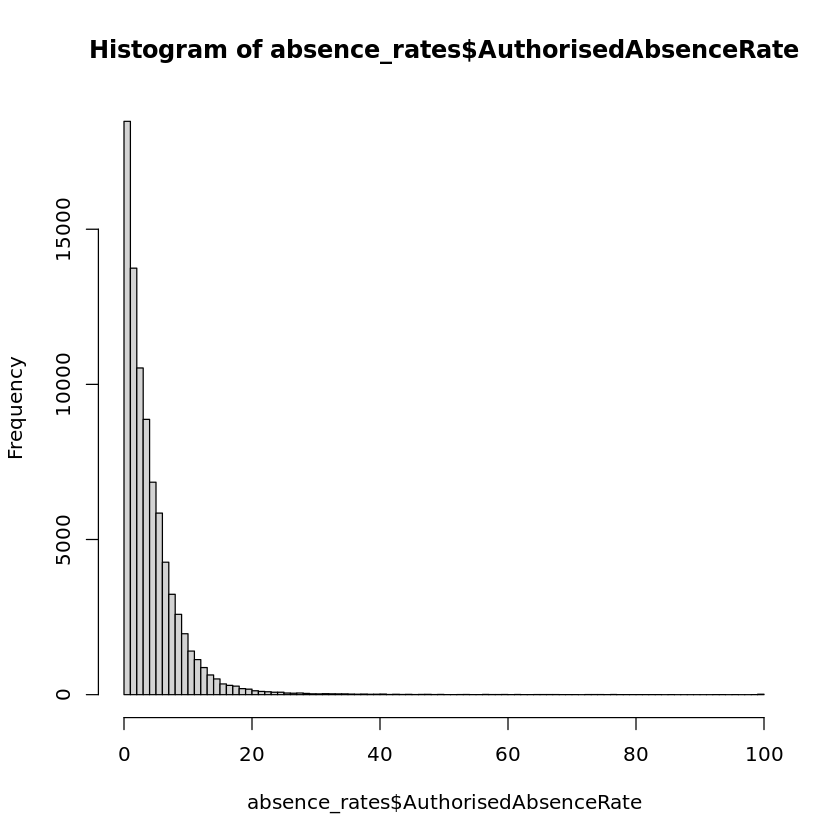

In [91]:
hist(absence_rates$AuthorisedAbsenceRate, breaks = 100)

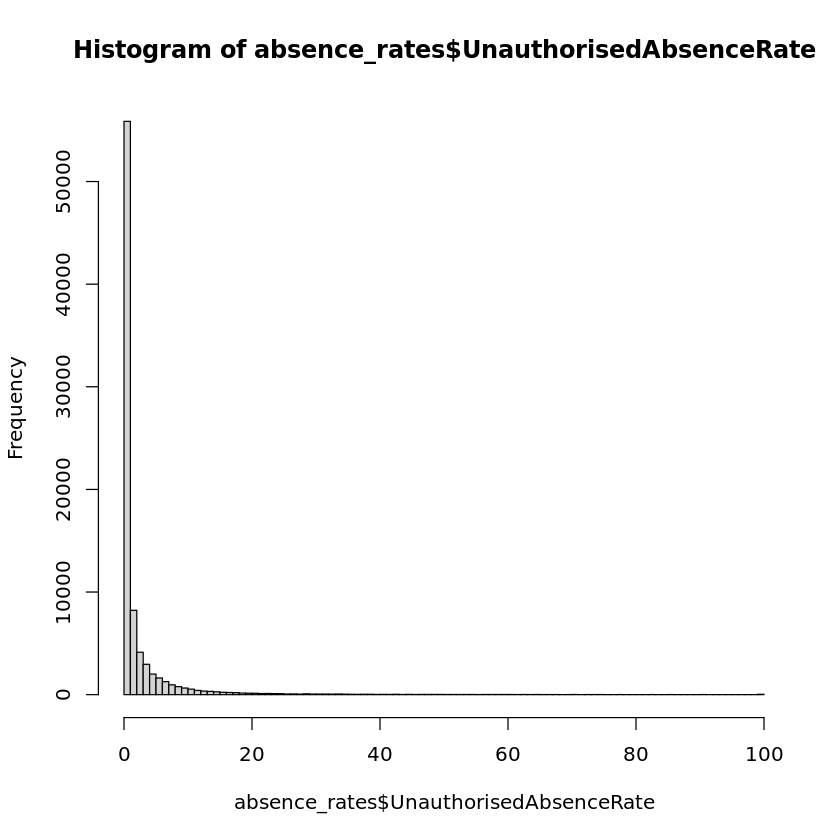

In [92]:
hist(absence_rates$UnauthorisedAbsenceRate, breaks = 100)

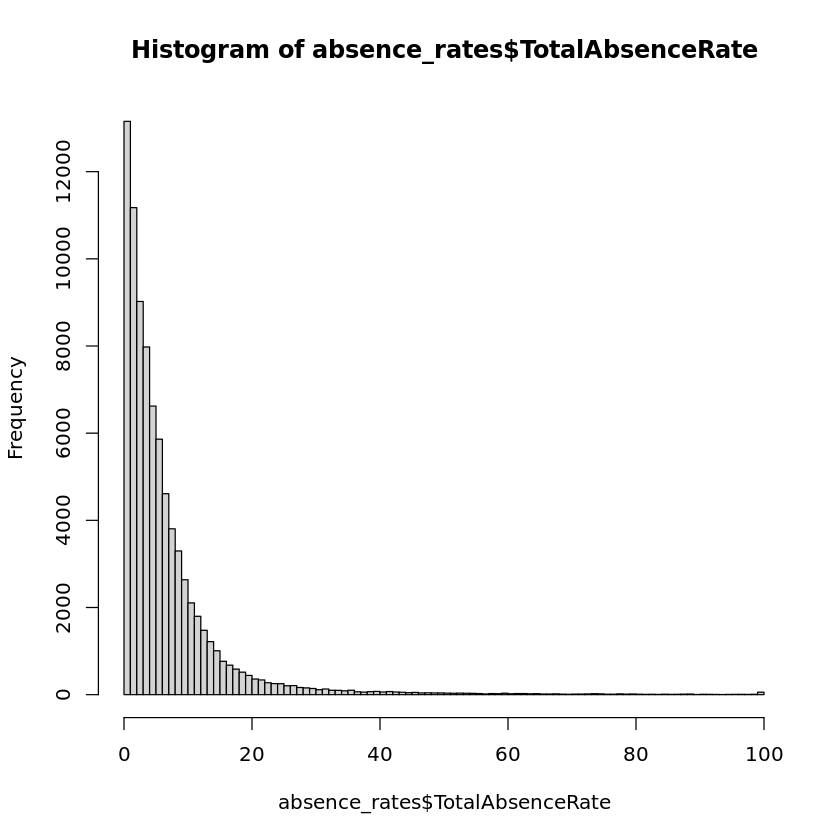

In [93]:
hist(absence_rates$TotalAbsenceRate, breaks = 100)

## Calculate overall rates

In [94]:
head(absence_final)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2012/2013,376,15,0,15
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2013/2014,378,2,0,2
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2014/2015,380,4,0,4
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2012/2013,376,37,0,37
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2013/2014,378,43,6,49
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2014/2015,312,52,0,52


In [95]:
absence_alltime <- absence_final |> 
    group_by(person_id) %>%
      summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
      )

In [96]:
head(absence_alltime)

person_id,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,1761,33,0,33
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,1690,154,6,160
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,1683,28,0,28
00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,1760,30,0,30
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,1742,21,264,285
00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7,1746,220,0,220


In [97]:
absence_alltime_rates <- absence_alltime |>
    mutate(
        AuthorisedAbsenceRate = (AuthorisedAbsence / SessionsPossible)*100,
        UnauthorisedAbsenceRate = (UnauthorisedAbsence / SessionsPossible)*100,
        TotalAbsenceRate = (OverallAbsence / SessionsPossible)*100
    ) |>
    select(-c(SessionsPossible, AuthorisedAbsence, UnauthorisedAbsence, OverallAbsence))

In [98]:
absence_alltime_rates

person_id,AuthorisedAbsenceRate,UnauthorisedAbsenceRate,TotalAbsenceRate
<chr>,<dbl>,<dbl>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,1.8739353,0.0000000,1.8739353
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,9.1124260,0.3550296,9.4674556
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,1.6636958,0.0000000,1.6636958
00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,1.7045455,0.0000000,1.7045455
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,1.2055109,15.1549943,16.3605052
00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7,12.6002291,0.0000000,12.6002291
001F42538A9E6E496F13CD05B5E9FE91EB3B20F0CEBECA1B76CC5E7151B7A0D4,6.3170441,0.1191895,6.4362336
00211975518FD5336E43850D59B5F5DDA7CD98B212760111CB40528BDECF3B1B,6.9892473,24.2703533,31.2596006
00237E9C21696BB29409630166F2D9CCEC24B83FB120AEDD878DDD54C6516B3D,3.2816229,1.0739857,4.3556086


### save as csv

In [99]:
# save as csv
write.csv(absence_alltime_rates, "data/additional_absence_alltime_rates.csv", row.names = FALSE)

## Explore absences

In [100]:
summary(absence_alltime_rates)

  person_id         AuthorisedAbsenceRate UnauthorisedAbsenceRate
 Length:17173       Min.   :  0.000       Min.   :  0.0000       
 Class :character   1st Qu.:  1.826       1st Qu.:  0.1143       
 Mode  :character   Median :  3.289       Median :  0.6532       
                    Mean   :  4.244       Mean   :  2.5564       
                    3rd Qu.:  5.536       3rd Qu.:  2.2878       
                    Max.   :100.000       Max.   :100.0000       
 TotalAbsenceRate 
 Min.   :  0.000  
 1st Qu.:  2.446  
 Median :  4.491  
 Mean   :  6.801  
 3rd Qu.:  8.103  
 Max.   :100.000  

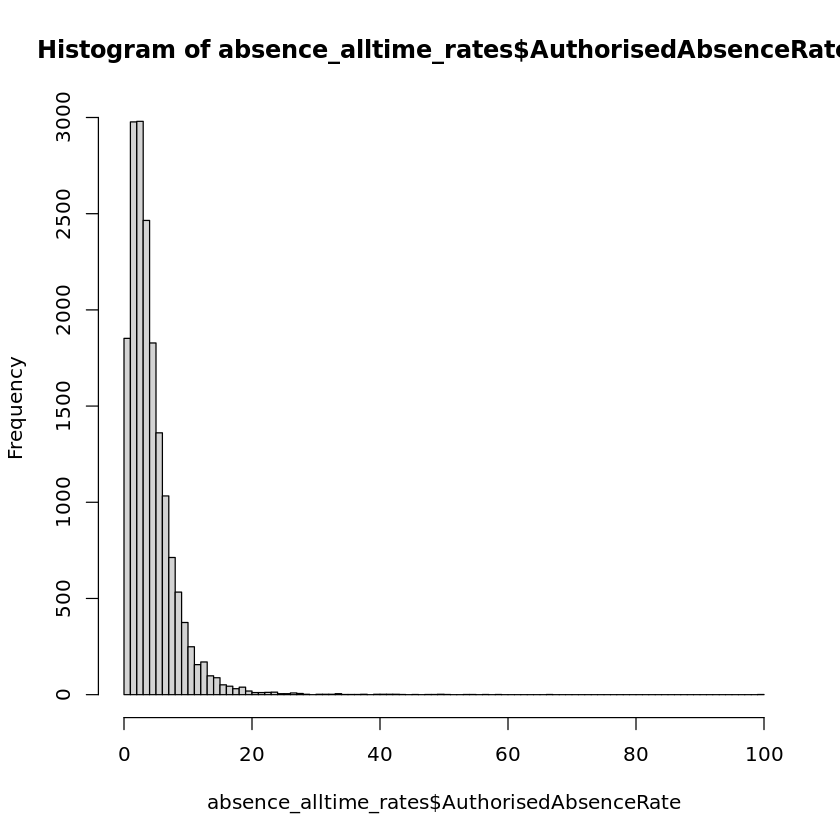

In [101]:
hist(absence_alltime_rates$AuthorisedAbsenceRate, breaks = 100)

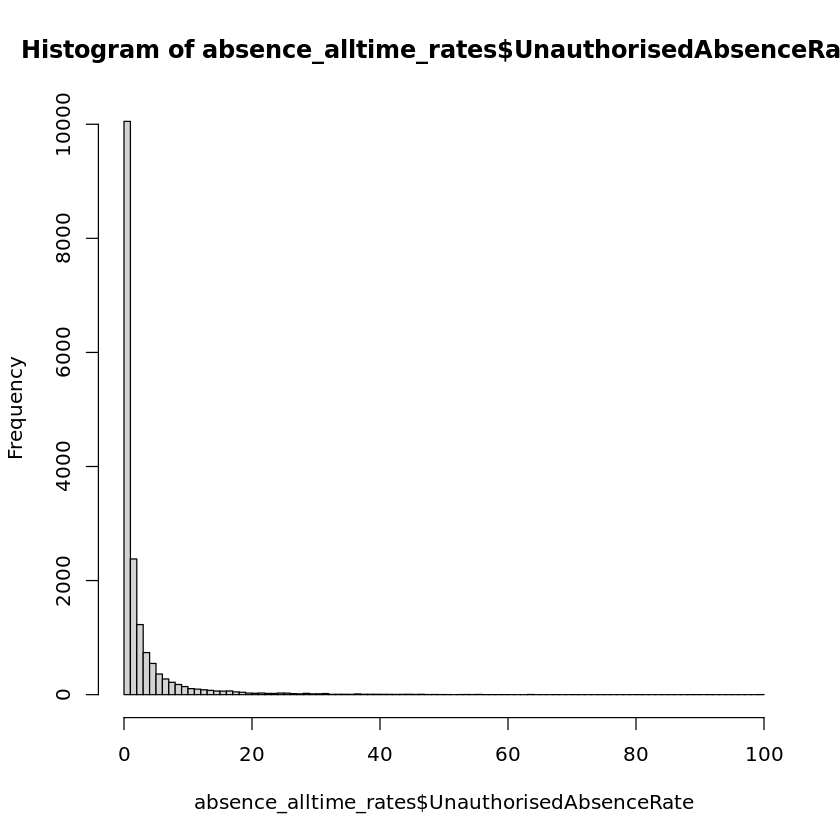

In [102]:
hist(absence_alltime_rates$UnauthorisedAbsenceRate, breaks = 100)

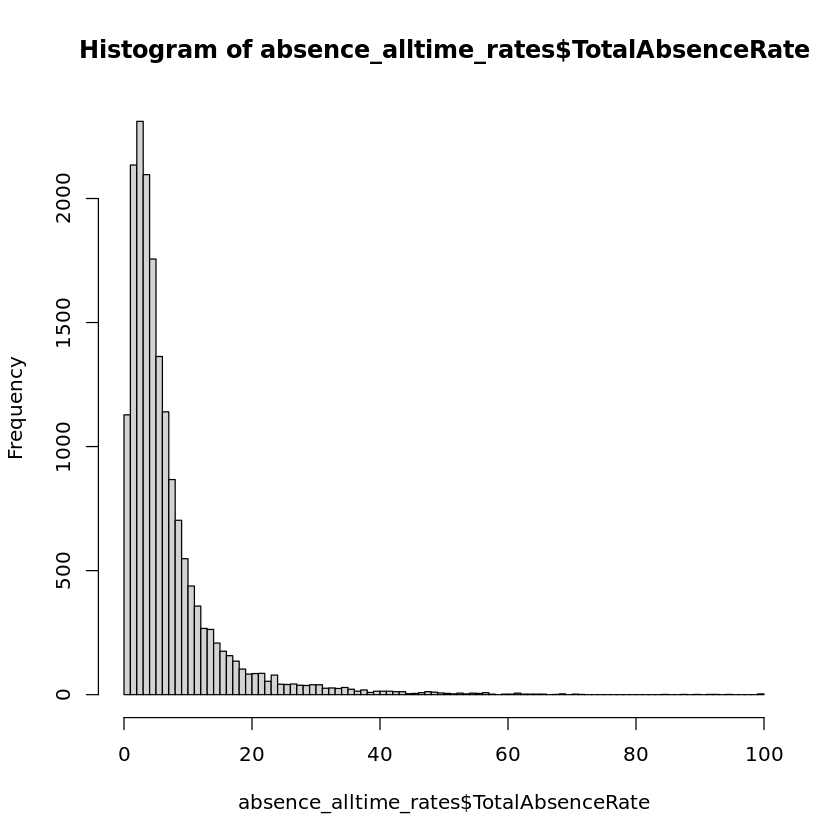

In [103]:
hist(absence_alltime_rates$TotalAbsenceRate, breaks = 100)

# merge with main person data

In [3]:
absence_alltime_rates <- read.csv("data/additional_absence_alltime_rates.csv", header = TRUE)

In [273]:
absence_alltime_rates |>
    summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
16962


In [1]:
data <- read.csv('data/additional_person_home_fsm_sen.csv', header = TRUE)

In [2]:
head(data)

,person_id,ever_SEN_support,first_SEN_support_year,SEN_support_need,ever_EHC_plan,first_EHC_plan_year,EHC_plan_need,no_SEN,birth_date,gender,CombinedEthnicity,cohort,DistCurrSch,IDACIScore_Home,LSOA11_Home,EAL,ever_fsm
,<chr>,<lgl>,<int>,<chr>,<lgl>,<int>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>
1,0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,FALSE,NA,NA,FALSE,NA,NA,TRUE,1999-09-15,F,White British,1999/00,2.45,0.04778,E01027555,0,0
2,00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,TRUE,2009,,FALSE,NA,NA,FALSE,1999-08-15,F,White British,1998/99,4.71,0.35519,E01010703,0,0
3,000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,FALSE,NA,NA,FALSE,NA,NA,TRUE,1998-11-15,M,South Asian,1998/99,0.33,0.37575,E01010742,0,0
4,00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,FALSE,NA,NA,FALSE,NA,NA,TRUE,2000-05-15,M,White British,1999/00,1.78,0.07161,E01010641,0,0
5,0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,TRUE,2008,,FALSE,NA,NA,FALSE,2000-08-15,F,White British,1999/00,0.76,0.44704,E01010655,0,1
6,00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7,TRUE,2007,,FALSE,NA,NA,FALSE,1999-09-15,M,South Asian,1999/00,1.29,0.41032,E01010626,0,1


In [6]:
join_absence_person <- data |> 
    left_join(absence_alltime_rates, by = join_by(person_id)) 

In [7]:
head(join_absence_person)

,person_id,ever_SEN_support,first_SEN_support_year,SEN_support_need,ever_EHC_plan,first_EHC_plan_year,EHC_plan_need,no_SEN,birth_date,gender,CombinedEthnicity,cohort,DistCurrSch,IDACIScore_Home,LSOA11_Home,EAL,ever_fsm,AuthorisedAbsenceRate,UnauthorisedAbsenceRate,TotalAbsenceRate
,<chr>,<lgl>,<int>,<chr>,<lgl>,<int>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,FALSE,NA,NA,FALSE,NA,NA,TRUE,1999-09-15,F,White British,1999/00,2.45,0.04778,E01027555,0,0,1.873935,0.0000000,1.873935
2,00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,TRUE,2009,,FALSE,NA,NA,FALSE,1999-08-15,F,White British,1998/99,4.71,0.35519,E01010703,0,0,9.112426,0.3550296,9.467456
3,000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,FALSE,NA,NA,FALSE,NA,NA,TRUE,1998-11-15,M,South Asian,1998/99,0.33,0.37575,E01010742,0,0,1.663696,0.0000000,1.663696
4,00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,FALSE,NA,NA,FALSE,NA,NA,TRUE,2000-05-15,M,White British,1999/00,1.78,0.07161,E01010641,0,0,1.704545,0.0000000,1.704545
5,0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,TRUE,2008,,FALSE,NA,NA,FALSE,2000-08-15,F,White British,1999/00,0.76,0.44704,E01010655,0,1,1.205511,15.1549943,16.360505
6,00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7,TRUE,2007,,FALSE,NA,NA,FALSE,1999-09-15,M,South Asian,1999/00,1.29,0.41032,E01010626,0,1,12.600229,0.0000000,12.600229


### save as csv

In [8]:
# save as csv
write.csv(join_absence_person, "data/additional_person_plus_absence.csv", row.names = FALSE)